# Compute MI(φ/ψ; Z) + attention pooling importance → pick 2 CVs

Questo notebook è **autonomo**: non assume che `mi_phi_psi_vs_latent.csv` esista.

È però **consistente con il tuo progetto**:
- usa gli stessi file di output del run (`latents.npy`, `attn_weights.npy`, `token_residue_ids.txt`)
- usa (se disponibile) la funzione del progetto per i diedri `pkgs.utils.compute_aligned_phi_psi(...)`
- stima la MI con `sklearn.feature_selection.mutual_info_regression` come nel tuo notebook MI
- seleziona 2 CV con penalità di ridondanza **basata sui time-series dei due angoli** (quindi richiede traiettoria/topologia)

---

## Input richiesti
Nel run output folder (es. `test05/output/`):
- `latents.npy` (T×d)
- `attn_weights.npy` (T×N)
- `token_residue_ids.txt` (N)

Per ricavare φ/ψ:
- Trajectory (es. `traj.xtc` / `traj.dcd`) + Topology (es. `top.pdb` / `top.gro`)


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_selection import mutual_info_regression

try:
    import mdtraj as md
    MDTraj_AVAILABLE = True
except Exception:
    MDTraj_AVAILABLE = False

print("MDTraj available:", MDTraj_AVAILABLE)


MDTraj available: True


In [3]:
# -----------------------
# CONFIG (EDIT THESE PATHS)
# -----------------------
OUTPUT_DIR = Path("../test05/output")   # <-- cambia qui

LATENTS_PATH = OUTPUT_DIR / "latents.npy"
ATTN_WEIGHTS_PATH = OUTPUT_DIR / "attn_weights.npy"
TOKEN_RESIDUES_PATH = OUTPUT_DIR / "token_residue_ids.txt"

TRAJ_PATH = Path("../test05/traj_skip100NoH.xtc")
TOP_PATH  = Path("../test05/2JOF-0-proteinNoH.pdb")

MI_N_NEIGHBORS = 10
RANDOM_STATE = 0

ALPHA = 0.7
LAMBDA = 0.8
TOPK = 50

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
for p in [LATENTS_PATH, ATTN_WEIGHTS_PATH, TOKEN_RESIDUES_PATH, TRAJ_PATH, TOP_PATH]:
    print(f"{p.name:24s} exists:", p.exists())


OUTPUT_DIR: /home/tedeschg/prj/cvformer/cvformer-test/test05/output
latents.npy              exists: True
attn_weights.npy         exists: True
token_residue_ids.txt    exists: True
traj_skip100NoH.xtc      exists: True
2JOF-0-proteinNoH.pdb    exists: True


## 1) Load latents + attention weights + token→residue mapping

In [4]:
Z = np.load(LATENTS_PATH)
if Z.ndim != 2:
    raise ValueError(f"latents.npy must be 2D (T,d). Got {Z.shape}")
T, d = Z.shape
print("Latents shape:", Z.shape)

attn_w = np.load(ATTN_WEIGHTS_PATH)
if attn_w.ndim != 2:
    raise ValueError(f"attn_weights.npy must be 2D (T,N). Got {attn_w.shape}")
T2, N = attn_w.shape
print("Attn weights shape:", attn_w.shape)

token_res = np.loadtxt(TOKEN_RESIDUES_PATH).astype(int)
if token_res.ndim != 1 or len(token_res) != N:
    raise ValueError(f"token_residue_ids.txt must have N={N} entries. Got {token_res.shape}")

common_T = min(T, T2)
Z = Z[:common_T]
attn_w = attn_w[:common_T]
print("Using common_T:", common_T)


Latents shape: (10440, 2)
Attn weights shape: (10440, 18)
Using common_T: 10440


## 2) Compute attention pooling importance per residue (median over time, aggregated over tokens)

In [5]:
unique_res = np.unique(token_res)
res_to_idx = {r:i for i,r in enumerate(unique_res)}
R = len(unique_res)

attn_by_res = np.zeros((common_T, R), dtype=float)
for tok in range(N):
    attn_by_res[:, res_to_idx[token_res[tok]]] += attn_w[:, tok]

attn_df = pd.DataFrame({
    "resid": unique_res,
    "attn_median": np.median(attn_by_res, axis=0),
    "attn_mean": np.mean(attn_by_res, axis=0),
}).sort_values("attn_median", ascending=False).reset_index(drop=True)

display(attn_df.head(20))


,resid,attn_median,attn_mean
0,17,0.072572,0.073108
1,18,0.070082,0.071992
2,16,0.068942,0.071039
3,15,0.066307,0.068182
4,14,0.066082,0.072730
5,11,0.064577,0.065965
6,13,0.062861,0.064093
7,10,0.061933,0.068749
8,12,0.061810,0.063257
9,1,0.058157,0.058125


## 3) Compute φ/ψ time-series aligned to `residue.index`

Preferisce `pkgs.utils.compute_aligned_phi_psi` se disponibile, altrimenti MDTraj fallback.


In [7]:
# Try to import project helper
if (Path.cwd() / "pkgs").exists():
    sys.path.insert(0, str(Path.cwd()))
else:
    # common case: notebook inside repo/notebooks
    repo_guess = (OUTPUT_DIR / ".." / "..").resolve()
    if (repo_guess / "pkgs").exists():
        sys.path.insert(0, str(repo_guess))

phi_ts, psi_ts = {}, {}

use_project_helper = False
try:
    from pkgs import utils as project_utils
    if hasattr(project_utils, "compute_aligned_phi_psi"):
        use_project_helper = True
except Exception as e:
    print("Project helper not available:", repr(e))

if use_project_helper:
    print("Using pkgs.utils.compute_aligned_phi_psi")
    traj = md.load(str(TRAJ_PATH), top=str(TOP_PATH))
    traj = traj[:common_T]
    out = project_utils.compute_aligned_phi_psi(traj)
    if isinstance(out, tuple) and len(out) >= 3:
        phi_arr, psi_arr, resid_list = np.asarray(out[0]), np.asarray(out[1]), np.asarray(out[2]).astype(int)
        if phi_arr.shape[0] != common_T and phi_arr.shape[1] == common_T:
            phi_arr = phi_arr.T
        if psi_arr.shape[0] != common_T and psi_arr.shape[1] == common_T:
            psi_arr = psi_arr.T
        phi_arr = phi_arr[:common_T]
        psi_arr = psi_arr[:common_T]
        for j, r in enumerate(resid_list):
            phi_ts[int(r)] = phi_arr[:, j]
            psi_ts[int(r)] = psi_arr[:, j]
    else:
        raise ValueError("Unexpected return from compute_aligned_phi_psi (expected tuple(phi,psi,resid_list)).")
else:
    if not MDTraj_AVAILABLE:
        raise ImportError("Need either project helper or mdtraj installed.")
    print("Fallback: mdtraj compute_phi/compute_psi")
    traj = md.load(str(TRAJ_PATH), top=str(TOP_PATH))[:common_T]
    phi_idx, phi = md.compute_phi(traj)
    psi_idx, psi = md.compute_psi(traj)

    phi_res = np.array([traj.topology.atom(int(q[1])).residue.index for q in phi_idx], dtype=int)
    psi_res = np.array([traj.topology.atom(int(q[1])).residue.index for q in psi_idx], dtype=int)

    for j, r in enumerate(phi_res):
        phi_ts[int(r)] = phi[:, j]
    for j, r in enumerate(psi_res):
        psi_ts[int(r)] = psi[:, j]

print("phi residues:", len(phi_ts), "psi residues:", len(psi_ts))


Using pkgs.utils.compute_aligned_phi_psi
phi residues: 18 psi residues: 18


## 4) MI estimation (MI(angle → each latent dim), sum over dims)

In [8]:
def mi_angle_vs_latents(angle_rad: np.ndarray, Z: np.ndarray, n_neighbors: int = 10, random_state: int = 0) -> float:
    a = np.asarray(angle_rad, dtype=float)
    mask = ~np.isnan(a)
    if mask.sum() < 10:
        return np.nan
    Zm = Z[mask]
    s = np.sin(a[mask])
    c = np.cos(a[mask])
    mi_s = mutual_info_regression(Zm, s, n_neighbors=n_neighbors, random_state=random_state)
    mi_c = mutual_info_regression(Zm, c, n_neighbors=n_neighbors, random_state=random_state)
    return float(np.sum(mi_s) + np.sum(mi_c))

def mi_between_angles(a1: np.ndarray, a2: np.ndarray, n_neighbors: int = 10, random_state: int = 0) -> float:
    a1 = np.asarray(a1, dtype=float)
    a2 = np.asarray(a2, dtype=float)
    mask = ~np.isnan(a1) & ~np.isnan(a2)
    if mask.sum() < 10:
        return np.nan
    X = np.column_stack([np.sin(a1[mask]), np.cos(a1[mask])])
    y1 = np.sin(a2[mask])
    y2 = np.cos(a2[mask])
    mi1 = mutual_info_regression(X, y1, n_neighbors=n_neighbors, random_state=random_state)
    mi2 = mutual_info_regression(X, y2, n_neighbors=n_neighbors, random_state=random_state)
    return float(np.sum(mi1) + np.sum(mi2))

all_res = sorted(set(phi_ts.keys()) | set(psi_ts.keys()))
rows = []
for r in all_res:
    phi = phi_ts.get(r, np.full(common_T, np.nan))
    psi = psi_ts.get(r, np.full(common_T, np.nan))
    mi_phi = mi_angle_vs_latents(phi, Z, n_neighbors=MI_N_NEIGHBORS, random_state=RANDOM_STATE)
    mi_psi = mi_angle_vs_latents(psi, Z, n_neighbors=MI_N_NEIGHBORS, random_state=RANDOM_STATE)

    if np.isnan(mi_phi) and np.isnan(mi_psi):
        best_angle, best_mi = None, np.nan
    elif np.isnan(mi_psi) or (not np.isnan(mi_phi) and mi_phi >= mi_psi):
        best_angle, best_mi = "phi", mi_phi
    else:
        best_angle, best_mi = "psi", mi_psi

    rows.append({"resid": int(r), "mi_phi": mi_phi, "mi_psi": mi_psi, "best_angle": best_angle, "best_mi": best_mi})

mi_df = pd.DataFrame(rows).sort_values("best_mi", ascending=False).reset_index(drop=True)
display(mi_df.head(20))


,resid,mi_phi,mi_psi,best_angle,best_mi
0,8,0.143938,1.419545,psi,1.419545
1,10,1.159076,1.399131,psi,1.399131
2,5,0.339734,1.222423,psi,1.222423
3,11,0.116248,0.938755,psi,0.938755
4,6,0.349618,0.904566,psi,0.904566
5,7,0.305256,0.874770,psi,0.874770
6,13,0.192214,0.867460,psi,0.867460
7,12,0.437239,0.816451,psi,0.816451
8,2,0.239561,0.770490,psi,0.770490
9,4,0.209036,0.740076,psi,0.740076


## 5) Merge MI + attention and compute combined score

In [9]:
def zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return x - mu
    return (x - mu) / sd

merged = mi_df.merge(attn_df[["resid","attn_median"]], on="resid", how="left").dropna(subset=["attn_median"]).copy()

merged["mi_z"] = zscore(merged["best_mi"].to_numpy())
merged["attn_z"] = zscore(merged["attn_median"].to_numpy())
merged["combined_score"] = ALPHA * merged["mi_z"] + (1-ALPHA) * merged["attn_z"]

merged = merged.sort_values("combined_score", ascending=False).reset_index(drop=True)
display(merged.head(25))


,resid,mi_phi,mi_psi,best_angle,best_mi,attn_median,mi_z,attn_z,combined_score
0,10,1.159076,1.399131,psi,1.399131,0.061933,1.654985,0.587191,1.334647
1,8,0.143938,1.419545,psi,1.419545,0.027149,1.703537,-1.299448,0.802641
2,11,0.116248,0.938755,psi,0.938755,0.064577,0.560070,0.730623,0.611236
3,13,0.192214,0.867460,psi,0.867460,0.062861,0.390508,0.637550,0.464621
4,12,0.437239,0.816451,psi,0.816451,0.061810,0.269193,0.580521,0.362592
5,5,0.339734,1.222423,psi,1.222423,0.014614,1.234718,-1.979329,0.270504
6,14,0.644975,0.336697,phi,0.644975,0.066082,-0.138631,0.812265,0.146638
7,2,0.239561,0.770490,psi,0.770490,0.051766,0.159884,0.035773,0.122651
8,6,0.349618,0.904566,psi,0.904566,0.033423,0.478756,-0.959123,0.047393
9,3,0.259205,0.672497,psi,0.672497,0.053199,-0.073174,0.113499,-0.017172


## 6) Select 2 CVs with redundancy penalty (requires time-series)

In [14]:
def get_series(resid: int, angle: str) -> np.ndarray:
    return phi_ts.get(resid, np.full(common_T, np.nan)) if angle=="phi" else psi_ts.get(resid, np.full(common_T, np.nan))

cands = merged.dropna(subset=["best_angle"]).head(TOPK).reset_index(drop=True)

cv1 = cands.iloc[0].to_dict()
cv1_series = get_series(int(cv1["resid"]), str(cv1["best_angle"]))

rows = []
for _, r in cands.iloc[1:].iterrows():
    resid = int(r["resid"])
    ang = str(r["best_angle"])
    series = get_series(resid, ang)
    red = mi_between_angles(series, cv1_series, n_neighbors=MI_N_NEIGHBORS, random_state=RANDOM_STATE)
    score2 = float(r["combined_score"]) - LAMBDA * (0.0 if np.isnan(red) else red)
    rows.append((resid, ang, r["best_mi"], r["attn_median"], r["combined_score"], red, score2))

cv2_df = pd.DataFrame(rows, columns=["resid","angle","best_mi","attn_median","combined_score","redundancy_mi","final_score"])
cv2_df = cv2_df.sort_values("final_score", ascending=False).reset_index(drop=True)
cv2 = cv2_df.iloc[0].to_dict()

print("CV1:", f"residue.index {int(cv1['resid'])} {cv1['best_angle']} | MI={cv1['best_mi']:.6f} | attn_med={cv1['attn_median']:.6f} | score={cv1['combined_score']:.3f}")
print("CV2:", f"residue.index {int(cv2['resid'])} {cv2['angle']} | MI={cv2['best_mi']:.6f} | attn_med={cv2['attn_median']:.6f} | score={cv2['combined_score']:.3f} | redundancy_mi={cv2['redundancy_mi']:.6f}")

display(cv2_df)


CV1: residue.index 10 psi | MI=1.399131 | attn_med=0.061933 | score=1.335
CV2: residue.index 8 psi | MI=1.419545 | attn_med=0.027149 | score=0.803 | redundancy_mi=0.577093


,resid,angle,best_mi,attn_median,combined_score,redundancy_mi,final_score
0,8,psi,1.419545,0.027149,0.802641,0.577093,0.340967
1,12,psi,0.816451,0.061810,0.362592,0.380387,0.058282
2,13,psi,0.867460,0.062861,0.464621,0.522108,0.046935
3,14,phi,0.644975,0.066082,0.146638,0.160834,0.017971
4,11,psi,0.938755,0.064577,0.611236,0.771202,-0.005726
5,5,psi,1.222423,0.014614,0.270504,0.631386,-0.234605
6,1,psi,0.589027,0.058157,-0.075459,0.240326,-0.267720
7,2,psi,0.770490,0.051766,0.122651,0.560174,-0.325488
8,6,psi,0.904566,0.033423,0.047393,0.518640,-0.367520
9,3,psi,0.672497,0.053199,-0.017172,0.486746,-0.406570


## 7) Plots + export

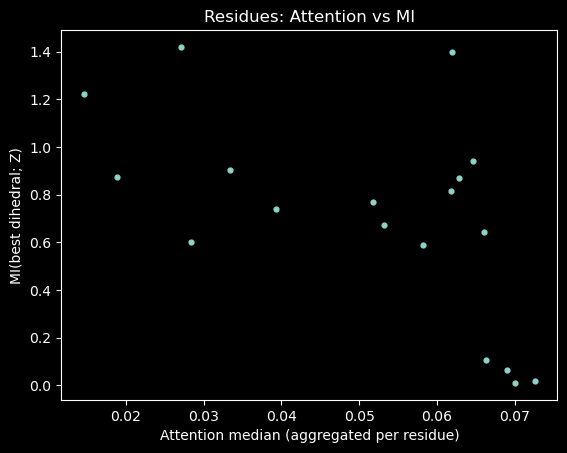

Wrote:
 - /home/tedeschg/prj/cvformer/cvformer-test/test05/output/cv_selection_independent/mi_phi_psi_vs_latent_recomputed.csv
 - /home/tedeschg/prj/cvformer/cvformer-test/test05/output/cv_selection_independent/combined_ranking_attention_mi.csv
 - /home/tedeschg/prj/cvformer/cvformer-test/test05/output/cv_selection_independent/selected_2_cvs.csv


In [11]:
plt.figure()
plt.scatter(merged["attn_median"], merged["best_mi"], s=12)
plt.xlabel("Attention median (aggregated per residue)")
plt.ylabel("MI(best dihedral; Z)")
plt.title("Residues: Attention vs MI")
plt.show()

out_dir = OUTPUT_DIR / "cv_selection_independent"
out_dir.mkdir(parents=True, exist_ok=True)

mi_df.to_csv(out_dir / "mi_phi_psi_vs_latent_recomputed.csv", index=False)
merged.to_csv(out_dir / "combined_ranking_attention_mi.csv", index=False)
cv2_df.to_csv(out_dir / "cv2_candidates_with_redundancy.csv", index=False)

pd.DataFrame([
    {"rank": 1, "resid": int(cv1["resid"]), "angle": cv1["best_angle"], "best_mi": cv1["best_mi"], "attn_median": cv1["attn_median"], "combined_score": cv1["combined_score"]},
    {"rank": 2, "resid": int(cv2["resid"]), "angle": cv2["angle"], "best_mi": cv2["best_mi"], "attn_median": cv2["attn_median"], "combined_score": cv2["combined_score"], "redundancy_mi": cv2["redundancy_mi"], "final_score": cv2["final_score"]},
]).to_csv(out_dir / "selected_2_cvs.csv", index=False)

print("Wrote:")
print(" -", (out_dir / "mi_phi_psi_vs_latent_recomputed.csv").resolve())
print(" -", (out_dir / "combined_ranking_attention_mi.csv").resolve())
print(" -", (out_dir / "selected_2_cvs.csv").resolve())
